In [1]:
import cv2

In [2]:
image1 = cv2.imread(
    "./data/processed/IMG_0301.JPG"
)

image2 = cv2.imread(
    "./data/processed/IMG_0302.JPG"
)

image3 = cv2.imread(
    "./data/processed/IMG_0303.JPG"
)

image4 = cv2.imread(
    "./data/processed/IMG_0304.JPG"
)

image5 = cv2.imread(
    "./data/processed/IMG_0305.JPG"
)

image6 = cv2.imread(
    "./data/processed/IMG_0306.JPG"
)

image7 = cv2.imread(
    "./data/processed/IMG_0307.JPG"
)

images = [image1, image2, image3, image4, image5, image6, image7]

Detector: sift
Número de keypoints: 476
Formato dos descritores: (476, 128)
Número de keypoints: 820
Formato dos descritores: (820, 128)
Número de keypoints: 899
Formato dos descritores: (899, 128)
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Número de keypoints: 754
Formato dos descritores: (754, 128)
Número de keypoints: 535
Formato dos descritores: (535, 128)
Processando: imagem 0 -> imagem 1


/home/luizl/repositorios/visao-computacional-mc919/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/luizl/repositorios/visao-computacional-mc919/panoramas/src/homography.py:161: RuntimeWarning: overflow encountered in scalar power
  J[2 * i] = [x / d, y / d, 1 / d, 0, 0, 0, -x * a / d**2, -y * a / d**2]
/home/luizl/repositorios/visao-computacional-mc919/panoramas/src/homography.py:168: RuntimeWarning: overflow encountered in scalar power
  J[2 * i + 1] = [0, 0, 0, x / d, y / d, 1 / d, -x * b / d**2, -y * b / d**2]


Processando: imagem 1 -> imagem 2
Processando: imagem 2 -> imagem 3
Processando: imagem 3 -> imagem 4
Processando: imagem 4 -> imagem 5
Processando: imagem 5 -> imagem 6
Canvas: 1939 x 823
Projetando imagem 0 (posição 0)
Projetando imagem 1 (posição 1)
Projetando imagem 2 (posição 2)
Projetando imagem 3 (posição 3)
Projetando imagem 4 (posição 4)
Projetando imagem 5 (posição 5)
Projetando imagem 6 (posição 6)
Blending: imagem 1 + panorama
Blending: imagem 2 + panorama
Blending: imagem 3 + panorama
Blending: imagem 4 + panorama
Blending: imagem 5 + panorama
Blending: imagem 6 + panorama


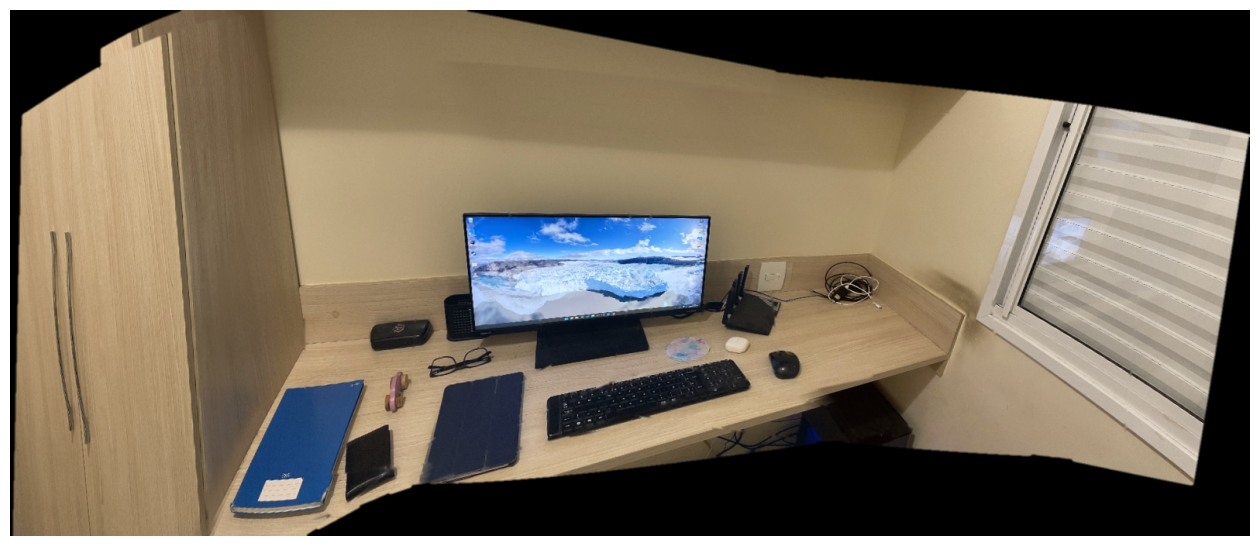

In [3]:
from src.features import draw_keypoints
from src.matching import match_all_images
from src.homography import estimate_all_homographies
from src.visualization import plot_image
from src.composition import cylindrical_stitching
from src.blending import optimal_seam_blending, remove_seam_lines


images_sift = draw_keypoints(images, method="sift")
matches_matrix, lowe_matrix = match_all_images([item["descriptors"] for item in images_sift], method="sift", ratio=0.7)
homographies, homography_metrics = estimate_all_homographies(lowe_matrix, [item["keypoints"] for item in images_sift], [0, 1, 2, 3, 4, 5, 6])
warps, masks, info = cylindrical_stitching(images, [0, 1, 2, 3, 4, 5, 6], homographies, 750)
result = optimal_seam_blending(warps, masks)
panorama = remove_seam_lines(result, masks, thickness=2)

plot_image(panorama)